## 1) Project Title: Crop Disease Prediction System
## 2) Group Members:

#### 25203001 - Kalyani Gadade
#### 25203002 - Rahul Jadhav
#### 25203004 - Shrihari Mane
#### 25203009 - Vedika Yadav

## 3) Class: SY(IT)
## 4) Subject: Machine Learning
## 5) 2025-26(Semester-II)

# Crop Disease Prediction System Using Machine Learning

## Project Overview
This project focuses on predicting crop diseases using machine learning techniques. 
The goal is to help farmers detect plant diseases at an early stage and take necessary actions to improve crop yield.

## Objective
- Identify diseases from crop symptoms along with temperature  
- Build an accurate prediction model  
- Provide an efficient and practical solution for agriculture

## Technologies Used
- Python  
- Machine Learning  
- Libraries: NumPy, Pandas, Matplotlib, Scikit-learn

In [97]:
import warnings
warnings.filterwarnings("ignore")

# Problem Statement 

#### Predict the crop disease based on the symtomps along with temperature and humidity

# Get the dataset

In [98]:
import pandas as pd

In [99]:
ds= pd.read_csv("crop_disease_symptom_dataset.csv")
ds

,Crop,Symptom1,Symptom2,Symptom3,Temperature,Humidity,Disease
0,Potato,dark lesions,leaf rot,wilting,21.3,High,Late Blight
1,Rice,yellowing,wilting,leaf streak,22.0,High,Bacterial Blight
2,Potato,brown spots,dry patches,yellowing,24.5,High,Early Blight
3,Tomato,pale spots,mold growth,leaf drop,34.6,Low,Leaf Mold
4,Wheat,orange pustules,leaf spots,yellowing,26.8,Medium,Rust
...,...,...,...,...,...,...,...
295,Rice,brown spots,leaf drying,yellow halo,26.8,High,Brown Spot
296,Tomato,yellow leaves,brown spots,leaf curl,26.3,Low,Early Blight
297,Corn,long gray lesions,leaf blight,dry leaves,23.8,Medium,Northern Leaf Blight
298,Tomato,yellow leaves,brown spots,leaf curl,30.8,High,Early Blight


## Dataset Description

The dataset used in this project contains information about crop conditions and environmental factors. 
It includes features such as symptoms observed in crops and temperature values, which are used to predict the type of disease affecting the crop.

### Features in Dataset
- Crop Symptoms  
- Temp
- Humidityrature  
- Disease Label (Target Variable)  

### Purpose of Dataset
The dataset helps in training the machine learning model to learn patterns between crop conditions and diseases, enabling accurate ction.

---

# Data Preprocessing

## In this step, the dataset is cleaned and prepared for model training. Proper preprocessing helps improve the accuracy and performance of the machine learning model.

### Steps Performed
- Handling missing values  
- Encoding categorical data  
- Feature selection  
- Splitting dataset into training and testing sets  

---

In [100]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Crop         300 non-null    object 
 1   Symptom1     300 non-null    object 
 2   Symptom2     300 non-null    object 
 3   Symptom3     300 non-null    object 
 4   Temperature  300 non-null    float64
 5   Humidity     300 non-null    object 
 6   Disease      300 non-null    object 
dtypes: float64(1), object(6)
memory usage: 16.5+ KB


In [101]:
ds.isna().sum()

Crop           0
Symptom1       0
Symptom2       0
Symptom3       0
Temperature    0
Humidity       0
Disease        0
dtype: int64

In [102]:
ds= ds.drop_duplicates()
ds

,Crop,Symptom1,Symptom2,Symptom3,Temperature,Humidity,Disease
0,Potato,dark lesions,leaf rot,wilting,21.3,High,Late Blight
1,Rice,yellowing,wilting,leaf streak,22.0,High,Bacterial Blight
2,Potato,brown spots,dry patches,yellowing,24.5,High,Early Blight
3,Tomato,pale spots,mold growth,leaf drop,34.6,Low,Leaf Mold
4,Wheat,orange pustules,leaf spots,yellowing,26.8,Medium,Rust
...,...,...,...,...,...,...,...
295,Rice,brown spots,leaf drying,yellow halo,26.8,High,Brown Spot
296,Tomato,yellow leaves,brown spots,leaf curl,26.3,Low,Early Blight
297,Corn,long gray lesions,leaf blight,dry leaves,23.8,Medium,Northern Leaf Blight
298,Tomato,yellow leaves,brown spots,leaf curl,30.8,High,Early Blight


In [103]:
ds["Crop"].unique()

array(['Potato', 'Rice', 'Tomato', 'Wheat', 'Corn'], dtype=object)

In [104]:
from sklearn.preprocessing import LabelEncoder

le0 = LabelEncoder()
ds["Crop"] = le0.fit_transform(ds["Crop"])

le1 = LabelEncoder()
ds["Symptom1"] = le1.fit_transform(ds["Symptom1"])

le2 = LabelEncoder()
ds["Symptom2"] = le2.fit_transform(ds["Symptom2"])

le3 = LabelEncoder()
ds["Symptom3"] = le3.fit_transform(ds["Symptom3"])

le4 = LabelEncoder()
ds["Humidity"] = le4.fit_transform(ds["Humidity"])

le5 = LabelEncoder()
ds["Disease"] = le5.fit_transform(ds["Disease"])

In [105]:
ds.head()

,Crop,Symptom1,Symptom2,Symptom3,Temperature,Humidity,Disease
0,1,1,5,5,21.3,0,4
1,2,8,8,4,22.0,0,0
2,1,0,1,8,24.5,0,3
3,3,4,7,2,34.6,1,5
4,4,3,6,8,26.8,2,8


In [107]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 299
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Crop         296 non-null    int32  
 1   Symptom1     296 non-null    int32  
 2   Symptom2     296 non-null    int32  
 3   Symptom3     296 non-null    int32  
 4   Temperature  296 non-null    float64
 5   Humidity     296 non-null    int32  
 6   Disease      296 non-null    int32  
dtypes: float64(1), int32(6)
memory usage: 11.6 KB


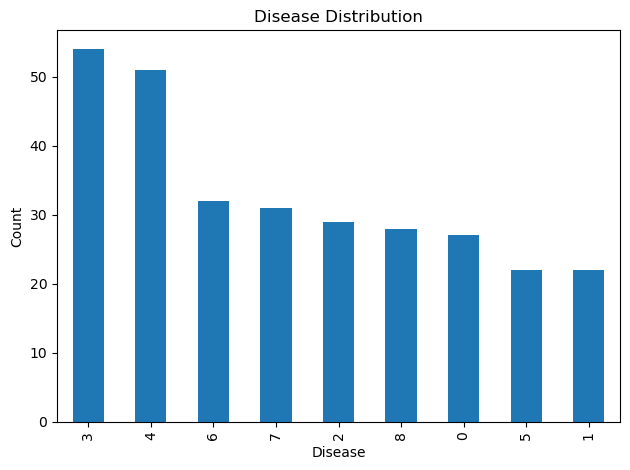

In [92]:
import matplotlib.pyplot as plt

ds['Disease'].value_counts().plot(kind='bar')

plt.title('Disease Distribution')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# X and Y variable

In [71]:
x = ds.drop("Disease", axis=1)
x.head()

,Crop,Symptom1,Symptom2,Symptom3,Temperature,Humidity
0,1,1,5,5,21.3,0
1,2,8,8,4,22.0,0
2,1,0,1,8,24.5,0
3,3,4,7,2,34.6,1
4,4,3,6,8,26.8,2


In [72]:
y = ds["Disease"]
y.head()

0    4
1    0
2    3
3    5
4    8
Name: Disease, dtype: int32

# Split data set into Training and Testing 

In [73]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Define the Model

In [74]:
from sklearn.svm import SVC

In [75]:
model = SVC(kernel='linear')

# Train the model

In [76]:
model.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# Test the model

In [77]:
y_pred= model.predict(x_test)

# Evaluation 

The performance of the trained model is evaluated using various metrics 
This helps in understanding how well the model is predicting crop diseasesat  

---

### Evaluation Metrics Used
- Accuracy
- Precision
- Recall
- f1 score
- Confusion Matrix
- Classification report

In [85]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

precision= precision_score(y_test, y_pred, average='weighted')
print("\nPrecision:", precision)

recall = recall_score(y_test, y_pred, average='weighted')
print("\nRecall:", recall)

f1 = f1_score(y_test, y_pred, average='weighted')
print("\nF1 Score:", f1)

Accuracy: 1.0

Precision: 1.0

Recall: 1.0

F1 Score: 1.0


In [86]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00        12
           4       1.00      1.00      1.00        13
           5       1.00      1.00      1.00         6
           6       1.00      1.00      1.00         7
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         7

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



# Deployment

In [44]:
crop_ = int(input("Enter crop (0-4): "))
sym1_ = int(input("Enter Symptom1 (0-8): "))
sym2_ = int(input("Enter Symptom2 (0-9): "))
sym3_ = int(input("Enter Symptom3 (0-8): "))
temp_ = float(input("Enter temperature: "))
hum_ = int(input("Enter humidity (0=Low,1=Medium,2=High): "))

Enter crop (0-4):  4
Enter Symptom1 (0-8):  6
Enter Symptom2 (0-9):  7
Enter Symptom3 (0-8):  6
Enter temperature:  28.7
Enter humidity (0=Low,1=Medium,2=High):  1


In [45]:
import numpy as np

data = np.array([[crop_, sym1_, sym2_, sym3_, temp_, hum_]], dtype=float)
prediction = model.predict(data)
predicted_disease = le5.inverse_transform(prediction)

print("Predicted Disease: ",predicted_disease[0])

Predicted Disease:  Bacterial Blight


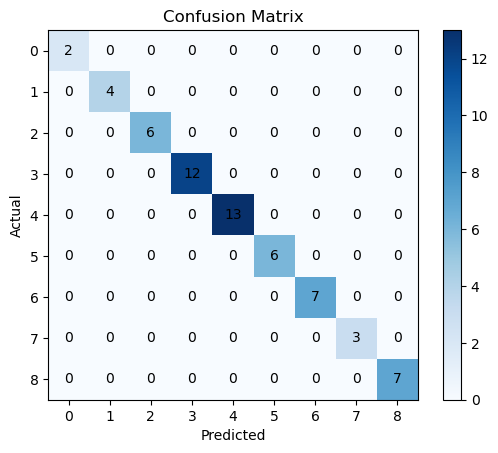

In [46]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

ticks = np.arange(len(cm))
plt.xticks(ticks)
plt.yticks(ticks)


for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.show()

## Conclusion

In this project, a machine learning model was successfully developed to predict crop diseases using symptoms and temperature data. 
The model was trained, tested, and evaluated using standard techniques, achieving reliable performance.

This system demonstrates how machine learning can be applied in agriculture to support early disease detection and improve crop productivity.

---

## Futurgorithms  
- Integrate image-based disease detection  
- Develop a web or mobile application for real-time usage  
- Combine with IoT sensors for smart agriculturlutions  

---